# 04 — Resampling buys you nothing

## The question

> I want hourly averages. There is a `reading` table with four million rows and a
> `reading_1h` continuous aggregate with under six thousand. Which do I query, and
> does the answer change?

The rollup exists for speed, and "use the rollup" is correct advice and an incomplete
argument, because `reading_1h` does not contain the same numbers as `reading`. On
this data the two disagree by **19 %** on a control signal and by **27 %** on the
flow meter, and neither disagreement is a rounding artefact or a bug. It is a
different question being answered.

This notebook works out which question, why the flow meter is the worst case, and
what to write when you want the other one.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from notebooks._data import connect, storm_window
from notebooks._style import apply_style, save, stamp, trend

apply_style()
pd.set_option("display.width", 130)

conn = connect()
VALVE = "AERATION:AHU-1:BLOWER_VALVE"
storm_start, storm_end = (pd.Timestamp(t) for t in storm_window())

readings = pd.read_sql("SELECT signal_id, ts, value FROM reading", conn)
hourly = (
    readings.set_index("ts")
    .groupby("signal_id")
    .value.resample("1h")
    .mean()
    .unstack("signal_id")
)
rollup = pd.read_sql(
    f"SELECT * FROM reading_1h WHERE signal_id = '{VALVE}' ORDER BY bucket", conn
)
print(f"{len(readings):,} readings, {hourly.shape[1]} signals")
print(f"reading_1h for {VALVE}: {len(rollup)} hourly buckets")

4,239,284 readings, 57 signals
reading_1h for AERATION:AHU-1:BLOWER_VALVE: 168 hourly buckets


```output
4,239,284 readings, 57 signals
reading_1h for AERATION:AHU-1:BLOWER_VALVE: 168 hourly buckets
```

## What an hourly bucket is not

The word "bucket" invites the assumption that a bucket is one sample. It is an
arbitrary number of samples, and the number changes every hour:

In [2]:
counts = (
    readings.set_index("ts")
    .groupby("signal_id")
    .value.resample("1h")
    .count()
    .unstack("signal_id")
)

summary = pd.DataFrame(
    {
        "hours": counts.notna().sum(),
        "min_n": counts.min(),
        "median_n": counts.median(),
        "max_n": counts.max(),
    }
)
summary = summary[summary.hours >= 100].sort_values("max_n", ascending=False)
print(summary.head(8).to_string())

                             hours   min_n  median_n   max_n
signal_id                                                   
AERATION:AHU-1:AIR_FLOW        168    12.0    3023.5  3600.0
AERATION:AHU-1:BLOWER_RPM      168    23.0    3569.0  3600.0
UTILITY:SITE:PLANT_POWER       168    19.0    3600.0  3600.0
AERATION:AHU-1:BLOWER_VALVE    168     5.0    1410.5  3600.0
PRIMARY:PRI-SCR-1:TORQUE       168  2545.0    2833.5  3200.0
EFFLUENT:DIS-CL-2:BACTI        168     0.0    1328.0  2952.0
EFFLUENT:FLOW:RESIDUAL_CL      168     0.0    1328.0  2952.0
SECONDARY:SEC-SCR-1:TORQUE     168  2478.0    2500.0  2879.0


```output
                             hours   min_n  median_n   max_n
signal_id                                                   
AERATION:AHU-1:AIR_FLOW        168    12.0    3023.5  3600.0
AERATION:AHU-1:BLOWER_RPM      168    23.0    3569.0  3600.0
UTILITY:SITE:PLANT_POWER       168    19.0    3600.0  3600.0
AERATION:AHU-1:BLOWER_VALVE    168     5.0    1410.5  3600.0
PRIMARY:PRI-SCR-1:TORQUE       168  2545.0    2833.5  3200.0
EFFLUENT:DIS-CL-2:BACTI        168     0.0    1328.0  2952.0
EFFLUENT:FLOW:RESIDUAL_CL      168     0.0    1328.0  2952.0
SECONDARY:SEC-SCR-1:TORQUE     168  2478.0    2500.0  2879.0
```

An hourly bucket holds anywhere from nothing to **3600** readings. These signals
declare a 1,000 ms sample rate, so 3,600 is a *full* hour and anything less means
the historian wrote fewer rows. For `AERATION:AHU-1:AIR_FLOW` the quietest hour has
**12** readings and the median hour about **3,024**; for the blower valve the
quietest has **5** and the median **1,410**.

Now the arithmetic that follows from that, which is the whole notebook:

In [3]:
# The mean of the hourly means gives every hour one vote.
# The mean of the readings gives every reading one vote.
# These are the same number only when every bucket holds the same count.

series = readings[readings.signal_id == VALVE]
buckets = hourly[VALVE].dropna()
weights = counts[VALVE].reindex(buckets.index)

unweighted = buckets.mean()  # every hour one vote
weighted = (buckets * weights).sum() / weights.sum()  # every reading one vote
raw = series.value.mean()  # what AVG(value) does in SQL

print(f"mean of {len(buckets)} hourly means : {unweighted:.6f}")
print(f"count-weighted mean of the same   : {weighted:.6f}")
print(f"AVG(value) over the raw readings  : {raw:.6f}")

# **An assertion, not a printed difference.** The first version printed
# `abs(weighted - raw)` in scientific notation and claimed `0.00e+00` — exactly
# zero. That is not a fact about the data. Both sides sum the same 168 terms in
# **a different order**, and floating-point addition is not associative, so the
# last bit depends on the platform's vector width and on which pairwise
# summation numpy was built with. The number is real and it is a property of the
# *machine*: on the CI runner it printed `1.33e-15`, on this laptop `0.00e+00`,
# from the same rows in the same database.
#
# So the claim is stated the only way it can be checked on two machines: are the
# two numbers equal to within floating-point noise? That is a yes/no about the
# arithmetic rather than a rendering of the noise.
within_noise = abs(weighted - raw) < 1e-9
print(f"the two agree to nine decimal places: {within_noise}")
assert within_noise, "the weighted mean is not AVG(value), and this notebook is wrong"

mean of 168 hourly means : 23.934729
count-weighted mean of the same   : 29.596180
AVG(value) over the raw readings  : 29.596180
the two agree to nine decimal places: True


```output
mean of 168 hourly means : 23.934729
count-weighted mean of the same   : 29.596180
AVG(value) over the raw readings  : 29.596180
the two agree to nine decimal places: True
```

**The count-weighted mean of the hourly means is `AVG(value)`**, to floating-point
precision — they differ by about a part in 10<sup>15</sup>, which is the rounding of
the last digit, and they are that close for any data, because it is the same sum
divided by the same count.

The gap between the two numbers is the point, and it is *not* floating-point noise:
**23.9 against 29.6** is a whole quarter. The two are equal only because the
weights happen to reconstruct the raw sum. Remove the weighting and you have a
different question, answered differently — which is the section below.

That means `AVG` over the raw table is not a shortcut that is close to the right
answer. It **is** the right answer to a specific question:

> *What is the average of the readings that were recorded?*

Bucketing to hourly and averaging the buckets answers a **different** question:

> *What is the average of the hours in which anything was recorded?*

Both are legitimate. Only one is what `AVG(value)` does, and the difference is not
small:

In [4]:
print(f"unweighted (each hour one vote) : {unweighted:.2f} %")
print(f"count-weighted (AVG(value))     : {raw:.2f} %")
print(f"difference                      : {100 * (unweighted - raw) / raw:+.1f} %")

unweighted (each hour one vote) : 23.93 %
count-weighted (AVG(value))     : 29.60 %
difference                      : -19.1 %


```output
unweighted (each hour one vote) : 23.93 %
count-weighted (AVG(value))     : 29.60 %
difference                      : -19.1 %
```

**-19.1 % on a control signal.** The historian samples when the value *moves*, so
hours when the blower was working have thousands of readings and hours when it was
not have a handful. Giving each hour one vote hands the quiet hours the same weight
as the busy ones, and the quiet hours are the ones with the low values.

## How large the error gets, across every signal

It is not one unlucky tag:

In [5]:
errors = []
for sig in hourly.columns:
    hours = hourly[sig].dropna()
    series = readings[readings.signal_id == sig].value.dropna()
    if len(hours) < 100 or len(series) < 1000:
        continue
    avg = series.mean()
    if not avg:
        continue
    errors.append((abs(hours.mean() - avg) / abs(avg), sig, avg, hours.mean()))

print(f"signals with >=100 hourly means and >=1000 readings: {len(errors)}")
for _, sig, avg, hours_mean in sorted(errors, reverse=True)[:8]:
    print(
        f"  {sig:28} AVG {avg:9.3f}   mean-of-hours {hours_mean:9.3f}   "
        f"{100 * (hours_mean - avg) / avg:+6.1f}%"
    )

signals with >=100 hourly means and >=1000 readings: 28
  INFLUENT:FLOW:FLOW           AVG  2457.453   mean-of-hours  1798.039    -26.8%
  AERATION:AHU-1:BLOWER_VALVE  AVG    29.596   mean-of-hours    23.935    -19.1%
  INFLUENT:LIFT:WETWELL_LEVEL  AVG     3.091   mean-of-hours     3.438    +11.2%
  EFFLUENT:FLOW:TURBIDITY      AVG    10.206   mean-of-hours     9.308     -8.8%
  EFFLUENT:FLOW:TSS            AVG    18.491   mean-of-hours    17.118     -7.4%
  SECONDARY:SEC-CL-1:OVERFLOW  AVG    18.514   mean-of-hours    17.142     -7.4%
  AERATION:AHU-1:ORCH          AVG    28.429   mean-of-hours    26.386     -7.2%
  INFLUENT:LIFT:FLOW           AVG  1827.919   mean-of-hours  1704.950     -6.7%


```output
signals with >=100 hourly means and >=1000 readings: 28
  INFLUENT:FLOW:FLOW           AVG  2457.453   mean-of-hours  1798.039    -26.8%
  AERATION:AHU-1:BLOWER_VALVE  AVG    29.596   mean-of-hours    23.935    -19.1%
  INFLUENT:LIFT:WETWELL_LEVEL  AVG     3.091   mean-of-hours     3.438    +11.2%
  EFFLUENT:FLOW:TURBIDITY      AVG    10.206   mean-of-hours     9.308     -8.8%
  EFFLUENT:FLOW:TSS            AVG    18.491   mean-of-hours    17.118     -7.4%
  SECONDARY:SEC-CL-1:OVERFLOW  AVG    18.514   mean-of-hours    17.142     -7.4%
  AERATION:AHU-1:ORCH          AVG    28.429   mean-of-hours    26.386     -7.2%
  INFLUENT:LIFT:FLOW           AVG  1827.919   mean-of-hours  1704.950     -6.7%
```

**The worst eight of 28 signals all disagree by at least 6.7 %**, and the worst is not
a valve. It is `INFLUENT:FLOW:FLOW`, at **-26.8 %**: a raw mean of 2457
m³/h against an hourly mean of 1798.

The prediction from the mechanism is specific, so test it. If the flow meter
disagrees with itself because it reports constantly during the storm, then removing
the storm's two hours should make the disagreement collapse:

In [6]:
flow = readings[readings.signal_id == "INFLUENT:FLOW:FLOW"].set_index("ts").value
flow_hours = flow.resample("1h").mean().dropna()


def in_storm(idx):
    return (idx >= storm_start) & (idx < storm_end)


def gap(readings_mean, hours_mean):
    return 100 * (hours_mean - readings_mean) / readings_mean


print(
    f"whole week   raw {flow.mean():7.1f}   hourly {flow_hours.mean():7.1f}   "
    f"gap {gap(flow.mean(), flow_hours.mean()):+6.1f} %"
)
calm, calm_hours = flow[~in_storm(flow.index)], flow_hours[~in_storm(flow_hours.index)]
print(
    f"storm out    raw {calm.mean():7.1f}   hourly {calm_hours.mean():7.1f}   "
    f"gap {gap(calm.mean(), calm_hours.mean()):+6.1f} %"
)
print(
    f"readings in the storm's two hours: {in_storm(flow.index).sum():,}"
    f" of {len(flow):,}"
)

whole week   raw  2457.5   hourly  1798.0   gap  -26.8 %
storm out    raw  1864.5   hourly  1775.6   gap   -4.8 %
readings in the storm's two hours: 1,162 of 3,733


```output
whole week   raw  2457.5   hourly  1798.0   gap  -26.8 %
storm out    raw  1864.5   hourly  1775.6   gap   -4.8 %
readings in the storm's two hours: 1,162 of 3,733
```

**The gap goes from -26.8 % to -4.8 %.** Two hours out of 168 account for
five-sixths of it. `1,162` of the meter's `3,733` readings are written inside the
storm, so a mean over readings is a mean of the storm and a mean over hours is a
mean of the week. Neither is wrong; the question is which one you were asked.

## And the window is yours to write

The rollup is 300 times smaller, so use it. But look at what it does *not* have:
a window. `reading_1h` holds every hour the database has ever aggregated, and a
query that forgets to say which ones returns an answer about all of them.

Ask a question with a boundary — the average lift-station flow on 27 September, the
day of the storm:

In [7]:
day = pd.Timestamp("2026-09-27", tz="UTC")
lift = "INFLUENT:LIFT:FLOW"
lift_raw = readings[
    (readings.signal_id == lift)
    & (readings.ts >= day)
    & (readings.ts < day + pd.Timedelta(days=1))
].value
lift_1h = pd.read_sql(
    f"SELECT bucket, mean, n FROM reading_1h WHERE signal_id = '{lift}'", conn
)
one_day = lift_1h[
    (lift_1h.bucket >= day) & (lift_1h.bucket < day + pd.Timedelta(days=1))
]

print(f"AVG(value), that day, from reading          : {lift_raw.mean():7.1f} m3/h")
print(
    f"avg(mean),  that day, from reading_1h       : {one_day['mean'].mean():7.1f} m3/h"
)
print(
    f"avg(mean),  NO window, from reading_1h      : {lift_1h['mean'].mean():7.1f} m3/h"
)
print(
    f"the forgotten window is off by              : "
    f"{100 * (lift_1h['mean'].mean() - lift_raw.mean()) / lift_raw.mean():+.1f} %"
)

AVG(value), that day, from reading          :  1980.0 m3/h
avg(mean),  that day, from reading_1h       :  1809.1 m3/h
avg(mean),  NO window, from reading_1h      :  1704.9 m3/h
the forgotten window is off by              : -13.9 %


```output
AVG(value), that day, from reading          :  1980.0 m3/h
avg(mean),  that day, from reading_1h       :  1809.1 m3/h
avg(mean),  NO window, from reading_1h      :  1704.9 m3/h
the forgotten window is off by              : -13.9 %
```

**Three answers to one question, and only one of them is `AVG(value)`.** The
readings say **1980.0** m³/h. The hourly rollup, with the window written correctly,
says **1809.1** — the estimator difference again, worth -8.6 %. And the rollup with
the window forgotten says **1704.9**, which is **-13.9 %** off and is an answer about
the whole week, not the day with the storm in it.

Nothing fails. The query is valid, the number is plausible, and that is the
dangerous shape for a bug to take: a wrong window returns a plausible number.

(On the plant's main database this bit harder, for a reason worth knowing. A
continuous aggregate is created once and is not rewritten when the raw table is
re-seeded, so `reading_1h` there held two more days than `reading`. That
database is not a fixed target, so it cannot be shown here — but it is why the
window clause is not optional.)

## The thing bucketing destroys

The arithmetic above is all about the aggregate. Here is what the aggregate throws
away.

An hourly bucket with one reading and an hourly bucket with a thousand are given the
same vote by `avg(mean)`, and both arrive at the rollup as a single number with no
memory of which it was:

In [8]:
lift_current = pd.read_sql(
    "SELECT bucket, n, mean, min, max FROM reading_1h "
    "WHERE signal_id = 'INFLUENT:LIFT:CURRENT' AND n > 0 "
    "ORDER BY n ASC, bucket LIMIT 6",
    conn,
)
print(lift_current.to_string(index=False))
print()
print("and at the other end, the same signal:")
full = pd.read_sql(
    "SELECT bucket, n, mean, min, max FROM reading_1h "
    "WHERE signal_id = 'INFLUENT:LIFT:CURRENT' ORDER BY n DESC, bucket LIMIT 3",
    conn,
)
print(full.to_string(index=False))

                   bucket  n      mean       min       max
2026-09-22 23:00:00+00:00  1 15.370421 15.370421 15.370421
2026-09-23 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-24 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-25 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-26 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-27 23:00:00+00:00  1 15.360452 15.360452 15.360452

and at the other end, the same signal:
                   bucket    n      mean  min       max
2026-09-27 19:00:00+00:00 1101 20.357147  0.0 40.751307
2026-09-22 19:00:00+00:00 1100 20.375653  0.0 40.751307
2026-09-23 19:00:00+00:00 1100 20.375653  0.0 40.751307


```output
                   bucket  n      mean       min       max
2026-09-22 23:00:00+00:00  1 15.370421 15.370421 15.370421
2026-09-23 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-24 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-25 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-26 23:00:00+00:00  1 15.370466 15.370466 15.370466
2026-09-27 23:00:00+00:00  1 15.360452 15.360452 15.360452

and at the other end, the same signal:
                   bucket    n      mean  min       max
2026-09-27 19:00:00+00:00 1101 20.357147  0.0 40.751307
2026-09-22 19:00:00+00:00 1100 20.375653  0.0 40.751307
2026-09-23 19:00:00+00:00 1100 20.375653  0.0 40.751307
```

Read the first table again. The hour beginning `23:00` on each day is a **single
reading** of 15.37 A — the historian wrote one row and then nothing for the rest of
the hour. The hours at the bottom average 20.38 A over about 1,100 readings each.

`avg(mean)` treats those as equal evidence. One measurement outweighs a thousand,
because the aggregate cannot tell the difference, and the lone reading sits inside
the signal's declared normal range of 20–70 A, so nothing looks wrong. The `n`
column is the fix, and it is why every rollup here carries one:

readings per hour, same signal: min 5, median 1410, max 3600


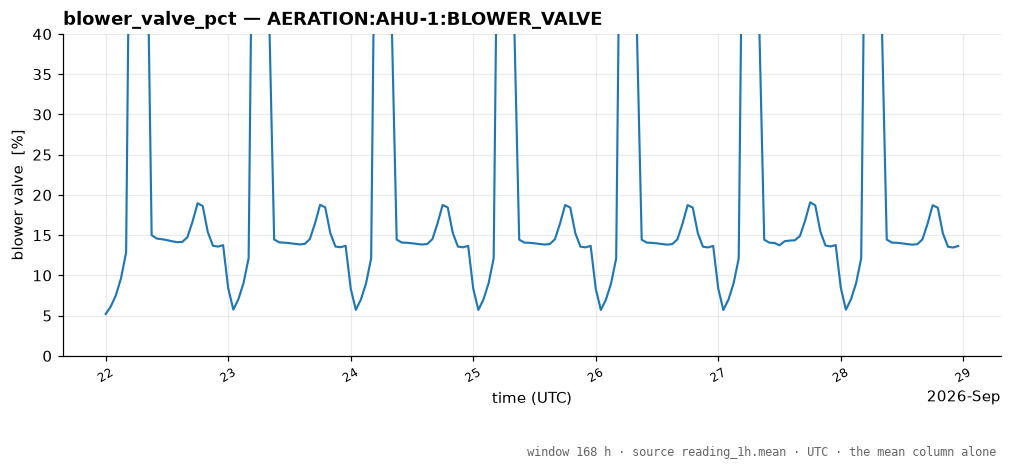

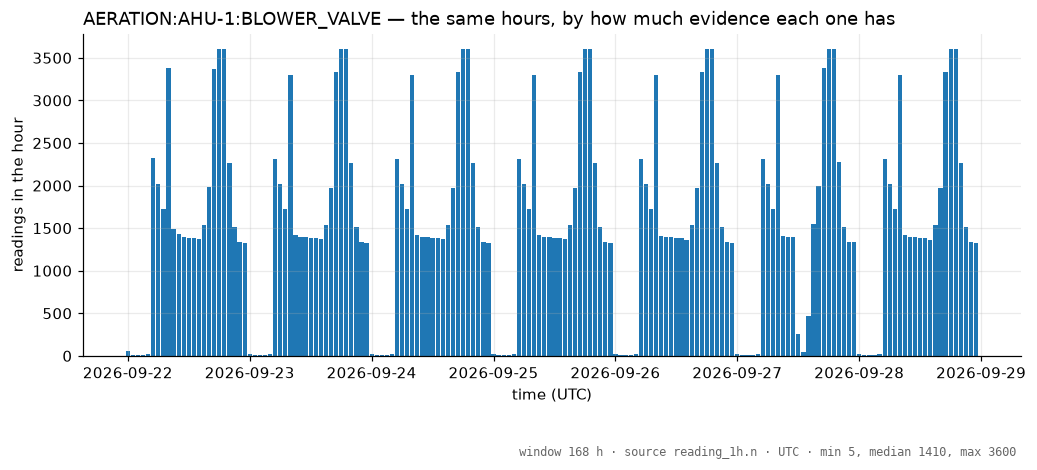

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.8))
trend(
    ax,
    {"hourly mean": rollup.set_index("bucket")["mean"]},
    VALVE,
    ylabel="blower valve  [%]",
)
ax.set_ylim(0, 40)
stamp(
    ax,
    window=f"{len(rollup)} h",
    source="reading_1h.mean",
    extra="the mean column alone",
)
save(fig, "04_valve_hourly_mean")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(rollup.bucket, rollup.n, width=0.035, color="#1f77b4")
ax.set_ylabel("readings in the hour")
ax.set_xlabel("time (UTC)")
ax.set_title(f"{VALVE} — the same hours, by how much evidence each one has", loc="left")
stamp(
    ax,
    window=f"{len(rollup)} h",
    source="reading_1h.n",
    extra=f"min {int(rollup.n.min())}, median {rollup.n.median():.0f}, "
    f"max {int(rollup.n.max())}",
)
save(fig, "04_valve_counts")

print(
    "readings per hour, same signal: "
    f"min {int(rollup.n.min())}, median {rollup.n.median():.0f}, "
    f"max {int(rollup.n.max())}"
)

```output
readings per hour, same signal: min 5, median 1410, max 3600
```

**One plot is smooth and one is a picket fence, and they describe the same 168
hours.** The first says "the valve averaged 24 %". The second says the average rests
on a number of readings that varies by a factor of 720 — from 5 in the quietest
hour to 3,600 in the busiest.

That is the trade resampling makes: a smoother series in exchange for the evidence
behind each point. Sometimes it is the right trade. It is never right by default,
and the factor of 720 is the size of the question you have to answer to know.

## What to write instead

Three rules, each of which is a different query:

**If you want the average of the recorded readings** — which is what a compliance
report means — use `AVG(value)` over `reading`. It is already correct, it needs no
bucketing, and it is the cheapest possible aggregate:

```sql
SELECT avg(value) AS mean_pct
FROM reading
WHERE signal_id = 'AERATION:AHU-1:BLOWER_VALVE'
  AND ts >= (SELECT max(ts) FROM reading) - interval '7 days';
```

**If you want the average hour** — which is what a time-series chart implies, and
which is what `avg(mean)` gives you — say so, and write the window:

```sql
SELECT avg(mean) AS mean_of_hours
FROM reading_1h
WHERE signal_id = 'AERATION:AHU-1:BLOWER_VALVE'
  AND bucket >= date_trunc('hour', (SELECT min(ts) FROM reading))
  AND bucket <  date_trunc('hour', (SELECT max(ts) FROM reading)) + interval '1 h';
```

**If you want to know whether an hour's value is worth anything**, carry the count
and treat it as evidence rather than as a number:

```sql
SELECT bucket, mean, n,
       CASE WHEN n = 0  THEN 'no data'
            WHEN n < 30 THEN 'thin'
            ELSE 'ok' END AS evidence
FROM reading_1h
WHERE signal_id = 'AERATION:AHU-1:BLOWER_VALVE'
ORDER BY n ASC
LIMIT 10;
```

That third query is the one a monitoring system should run, and it is not a query
that aggregates at all.

## Takeaways

- **`AVG(value)` is the count-weighted mean, exactly.** The count-weighted mean of
  hourly means equals it to floating-point precision, for any data. Bucketing does
  not approximate `AVG`; it computes something else.
- **The two disagree by up to 27 % on this plant.** The worst is the flow meter, at
  **-26.8 %**, and it is the storm: remove two hours of 168 and it falls to
  **-4.8 %**. The blower valve, a control signal, is next at **-19.1 %**.
- **The estimator changes because the buckets are unequal**, and they are very
  unequal: from 5 readings to 3,600 in an hour, on one signal.
- **A rollup has no window of its own.** Forgetting the clause is worth **-13.9 %**
  on the storm day and raises no error, because the query is valid and the number is
  plausible.
- **A bucket with one reading gets the same vote as one with a thousand**, and the
  `mean` column cannot tell you. That is what the `n` column is for.

## Exercises

1. **Prove the identity, generally.** `AVG(value)` equals the count-weighted mean
   of bucket means whenever the buckets partition the readings. Find a case where
   it does *not* — overlapping buckets, or a window that cuts a bucket in half —
   and quantify the error.
2. **Find the second storm.** Ranking by disagreement found the flow meter by
   accident. Remove each signal's *own* busiest two hours and recompute the gap:
   which signals have their disagreement explained the way the flow meter's was,
   and which are not?
3. **Choose the window that cuts a bucket.** Repeat the storm-day question with the
   window `12:30` to `14:30`. Which of `reading_1h` and `reading` can answer it, and
   what would you use instead?
4. **The spike that survives.** Find an hour where a genuine transient is visible
   in the raw readings and absent from the hourly mean. Then find the smallest
   bucket width that still shows it — and say what that width does to the noise.
5. **Which estimator for which question?** For each of these, name the estimator and
   defend it: a regulatory compliance figure, a chart on a dashboard, and a model
   that predicts the next hour.

---

**Next:** [05 — Autocorrelation](05-autocorrelation.ipynb) ·
**Back to the series** [README](README.md) ·
**Previous:** [03 — Choosing your tier](03-choosing-a-tier.ipynb)